In [1]:
!pip install rasterio

In [2]:
import pickle
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:

# Check if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

True


In [4]:
stacked_rasters = np.load('stacked_rasters.npy')

print(stacked_rasters.shape)


(13115, 10460, 6)


In [5]:
road_mask = np.load('road_mask.npy')

print(road_mask.shape)


(13115, 10460)


In [6]:
class RoadDataset(Dataset):
    def __init__(self, stacked_rasters, road_masks, sector_size=(256, 256)):
        """
        Args:
            stacked_rasters (np.array): The stacked rasters (height, width, channels).
            road_masks (np.array): The road masks (height, width).
            sector_size (tuple): The size of each sector to be extracted (height, width).
        """
        self.stacked_rasters = stacked_rasters  # Shape: (height, width, channels)
        self.road_masks = road_masks  # Shape: (height, width)
        self.sector_size = sector_size  # Tuple (sector_height, sector_width)
        
        # Calculate how many patches we can make based on the image size and patch size
        self.num_patches = self.calculate_num_patches()

    def __len__(self):
        # Since we have one large image, the length of the dataset is the number of patches
        return self.num_patches

    def calculate_num_patches(self):
        """
        Calculates the total number of patches that can be generated from the large image
        based on the patch size.
        
        Returns:
            int: Total number of patches
        """
        height, width, _ = self.stacked_rasters.shape  # Get the dimensions of the raster
        patch_height, patch_width = self.sector_size  # Get the patch dimensions
        
        # Calculate the number of patches that fit in the height and width
        num_patches_height = (height - patch_height) // patch_height + 1
        num_patches_width = (width - patch_width) // patch_width + 1
        
        return num_patches_height * num_patches_width

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the sample to fetch. In this case, it will refer to a specific patch.

        Returns:
            x (torch.Tensor): The input raster image sector as a tensor.
            y (torch.Tensor): The corresponding road mask sector as a tensor.
        """
        # Since we only have one image, idx is used to determine which patch to extract
        raster = self.stacked_rasters  # The single large raster
        mask = self.road_masks  # The corresponding mask for the large image

        # Calculate the position of the patch based on idx
        patch_height, patch_width = self.sector_size
        num_patches_height = (raster.shape[0] - patch_height) // patch_height + 1
        num_patches_width = (raster.shape[1] - patch_width) // patch_width + 1
        
        # Determine the row and column of the patch in the grid of patches
        row = idx // num_patches_width
        col = idx % num_patches_width
        
        # Calculate the coordinates of the top-left corner of the patch
        start_y = row * patch_height
        start_x = col * patch_width
        
        # Extract the patch from the raster and mask
        sector_raster = raster[start_y:start_y+patch_height, start_x:start_x+patch_width, :]
        sector_mask = mask[start_y:start_y+patch_height, start_x:start_x+patch_width]

        # Convert the sector to torch tensors
        x = torch.tensor(sector_raster, dtype=torch.float32)
        y = torch.tensor(sector_mask, dtype=torch.float32)

        return x, y



In [7]:
sector_size=(256, 256)

In [8]:
dataset = RoadDataset(stacked_rasters, road_mask, sector_size)

# Print the total number of patches
print(f"Total number of patches: {len(dataset)}")

Total number of patches: 2040


In [9]:
# Splitting dataset into train and test using sklearn's train_test_split
train_idx, test_idx = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=42)

# Create subsets for training and testing
train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

del dataset


In [10]:
# Set up DataLoader for batching
batch_size = 32

In [11]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Example of iterating over the DataLoader to fetch batches
# for batch_idx, (input_batch, mask_batch) in enumerate(train_loader):
#     print(f"Batch {batch_idx + 1} - Input shape: {input_batch.shape}, Mask shape: {mask_batch.shape}")
#     if batch_idx == 2:  # Only print the first 3 batches as an example
#         break
# Example of iterating over the DataLoader to fetch batches
for batch_idx, (input_batch, mask_batch) in enumerate(train_loader):
    # Reorder input_batch shape to [batch_size, channels, height, width]
    input_batch = input_batch.permute(0, 3, 1, 2)  # Converts [32, 256, 256, 6] -> [32, 6, 256, 256]
    
    # Add channel dimension to mask_batch (if necessary, depending on the network's expectation)
    mask_batch = mask_batch.unsqueeze(1)  # Converts [32, 256, 256] -> [32, 1, 256, 256]
    
    print(f"Batch {batch_idx + 1} - Input shape: {input_batch.shape}, Mask shape: {mask_batch.shape}")
    
    if batch_idx == 2:  # Only print the first 3 batches as an example
        break


Batch 1 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])
Batch 2 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])
Batch 3 - Input shape: torch.Size([32, 6, 256, 256]), Mask shape: torch.Size([32, 1, 256, 256])


In [12]:
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(UNetGenerator, self).__init__()
        
        # Encoder (downsampling)
        self.down1 = self.conv_block(in_channels, 64)
        self.down2 = self.conv_block(64, 128)
        self.down3 = self.conv_block(128, 256)
        self.down4 = self.conv_block(256, 512)
        self.down5 = self.conv_block(512, 512)
        self.down6 = self.conv_block(512, 512)
        self.down7 = self.conv_block(512, 512)
        
        # Bottleneck
        self.bottleneck = self.conv_block(512, 512)
        
        # Decoder (upsampling)
        self.up1 = self.upconv_block(512, 512)
        self.up2 = self.upconv_block(512, 512)
        self.up3 = self.upconv_block(512, 512)
        self.up4 = self.upconv_block(512, 256)
        self.up5 = self.upconv_block(256, 128)
        self.up6 = self.upconv_block(128, 64)
        
        # Channel reduction layers for skip connections
        self.reduce_512_1 = nn.Conv2d(1024, 512, kernel_size=1)  # For up1 + down7
        self.reduce_512_2 = nn.Conv2d(1024, 512, kernel_size=1)  # For up2 + down6
        self.reduce_512_3 = nn.Conv2d(1024, 512, kernel_size=1)  # For up3 + down5
        self.reduce_256 = nn.Conv2d(768, 256, kernel_size=1)     # For up4 + down4
        self.reduce_128 = nn.Conv2d(384, 128, kernel_size=1)     # For up5 + down3
        self.reduce_64 = nn.Conv2d(192, 64, kernel_size=1)       # For up6 + down2
        
        # Final convolution (output layer)
        self.final = nn.Conv2d(64, out_channels, kernel_size=3, stride=1, padding=1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
    
    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        down1 = self.down1(x)
        down2 = self.down2(down1)
        down3 = self.down3(down2)
        down4 = self.down4(down3)
        down5 = self.down5(down4)
        down6 = self.down6(down5)
        down7 = self.down7(down6)
        
        # Bottleneck
        bottleneck = self.bottleneck(down7)
        
        # Decoder with skip connections
        up1 = self.up1(bottleneck)
        up1 = torch.cat([up1, down7], dim=1)  # skip connection
        up1 = self.reduce_channels(up1, 512, 1)  # Reduce channels to 512 after concat
        
        up2 = self.up2(up1)
        up2 = torch.cat([up2, down6], dim=1)  # skip connection
        up2 = self.reduce_channels(up2, 512, 2)  # Reduce channels to 512 after concat
        
        up3 = self.up3(up2)
        up3 = torch.cat([up3, down5], dim=1)  # skip connection
        up3 = self.reduce_channels(up3, 512, 3)  # Reduce channels to 512 after concat
        
        up4 = self.up4(up3)
        up4 = torch.cat([up4, down4], dim=1)  # skip connection
        up4 = self.reduce_channels(up4, 256)  # Reduce channels to 256 after concat
        
        up5 = self.up5(up4)
        up5 = torch.cat([up5, down3], dim=1)  # skip connection
        up5 = self.reduce_channels(up5, 128)  # Reduce channels to 128 after concat
        
        up6 = self.up6(up5)
        up6 = torch.cat([up6, down2], dim=1)  # skip connection
        up6 = self.reduce_channels(up6, 64)  # Reduce channels to 64 after concat
        
        # Final layer
        out = self.final(up6)
        return out
    
    def reduce_channels(self, x, target_channels, idx=None):
        # Use the appropriate pre-defined layer based on target channels
        if target_channels == 512:
            if idx == 1:
                return self.reduce_512_1(x)
            elif idx == 2:
                return self.reduce_512_2(x)
            elif idx == 3:
                return self.reduce_512_3(x)
        elif target_channels == 256:
            return self.reduce_256(x)
        elif target_channels == 128:
            return self.reduce_128(x)
        elif target_channels == 64:
            return self.reduce_64(x)
        else:
            raise ValueError(f"No reduction layer defined for target_channels={target_channels}")

In [13]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=6):  # 3 for input image + 3 for the target image
        super(PatchGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)  # Output 1 channel (real or fake)
        )

    def forward(self, x):
        return self.model(x)


In [14]:
# Adversarial loss (binary cross-entropy)
adversarial_loss = nn.BCEWithLogitsLoss()

# L1 loss
l1_loss = nn.L1Loss()

def compute_loss(disc_real, disc_fake, gen_output, real_mask, lambda_l1=100):
    # Calculate adversarial loss
    valid = torch.ones_like(disc_real, dtype=torch.float32)
    fake = torch.zeros_like(disc_fake, dtype=torch.float32)
    
    loss_D_real = adversarial_loss(disc_real, valid)
    loss_D_fake = adversarial_loss(disc_fake, fake)
    loss_D = (loss_D_real + loss_D_fake) / 2
    
    # Generator loss
    loss_GAN = adversarial_loss(disc_fake, valid)
    
    # L1 loss
    loss_L1 = l1_loss(gen_output, real_mask) * lambda_l1
    
    # Total generator loss
    loss_G = loss_GAN + loss_L1
    
    return loss_G, loss_D


In [15]:
# # Initialize the models
# generator = UNetGenerator(in_channels=6, out_channels=1)  # 6 input channels (stacked rasters), 1 output channel (road mask)
# discriminator = PatchGANDiscriminator(in_channels=7)  # 6 input channels + 1 output channel

# # Move both models to the GPU
# generator = generator.to(device)   # Move the generator to GPU
# discriminator = discriminator.to(device)   # Move the discriminator to GPU

# # Set up optimizers
# optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.00015, betas=(0.5, 0.999))

# num_epochs = 100


In [16]:
# Define the path to your checkpoint
checkpoint_path = 'gan_checkpoint_epoch_29_d_loss_0.1956.pt'

# Load the checkpoint
checkpoint = torch.load(checkpoint_path)

# Extract the information from the checkpoint
epoch = checkpoint['epoch']
generator_state_dict = checkpoint['generator_state_dict']
discriminator_state_dict = checkpoint['discriminator_state_dict']
optimizer_G_state_dict = checkpoint['optimizer_G_state_dict']
optimizer_D_state_dict = checkpoint['optimizer_D_state_dict']
g_loss = checkpoint['g_loss']
d_loss = checkpoint['d_loss']

# Reinitialize the models (same architecture as before)
generator = UNetGenerator(in_channels=6, out_channels=1).to(device)
discriminator = PatchGANDiscriminator(in_channels=7).to(device)

# Reinitialize optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.00015, betas=(0.5, 0.999))

# Load the state dictionaries into the models and optimizers
generator.load_state_dict(generator_state_dict)
discriminator.load_state_dict(discriminator_state_dict)

optimizer_G.load_state_dict(optimizer_G_state_dict)
optimizer_D.load_state_dict(optimizer_D_state_dict)

# Set models to training mode if needed
generator.train()
discriminator.train()

# Optionally, print the last loss values if you want to continue from where you left off
print(f"Resuming training from epoch {epoch}, Generator loss: {g_loss}, Discriminator loss: {d_loss}")

num_epochs = 4


Resuming training from epoch 29, Generator loss: 3.1756648923836504, Discriminator loss: 0.19558571804972255


In [17]:
# Your improved training loop with discriminator loss monitoring and additional improvements
for epoch in range(num_epochs):
    # Track average losses for the epoch
    epoch_d_losses = []
    epoch_g_losses = []
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to GPU
        inputs, targets = inputs.cuda(), targets.cuda()
        
        # Ensure both tensors have the same number of dimensions
        if len(targets.shape) == 3:  # If targets has shape [batch_size, height, width]
            targets = targets.unsqueeze(1)  # Adds a channel dimension: [batch_size, 1, height, width]
        
        # Convert from [batch_size, height, width, channels] to [batch_size, channels, height, width]
        inputs = inputs.permute(0, 3, 1, 2)  
        
        batch_size = inputs.size(0)
        
        #############################
        # Train the discriminator (with adaptive training)
        #############################
        d_loss_threshold = 0.3
        max_d_train_iterations = 3  # Maximum number of D training iterations per batch
        
        d_train_iterations = 0
        d_loss = 0
        
        while d_train_iterations < max_d_train_iterations:
            optimizer_D.zero_grad()
            
            # Real images
            real_combined = torch.cat([inputs, targets], dim=1)
            real_pred = discriminator(real_combined)
            
            # First generate output from generator
            with torch.no_grad():  # Don't track gradients for G when training D
                gen_output = generator(inputs)
                # Resize generator output to match input size if needed
                gen_output = F.interpolate(gen_output, size=(inputs.shape[2], inputs.shape[3]), 
                                          mode='bilinear', align_corners=True)
            
            # Create labels with slight label smoothing for stability
            real_labels = torch.ones(batch_size, 1, real_pred.shape[2], real_pred.shape[3], device=device)
            real_labels = torch.full_like(real_labels, 0.9, device=device)  # Label smoothing: use 0.9 instead of 1
            fake_labels = torch.zeros(batch_size, 1, real_pred.shape[2], real_pred.shape[3], device=device)
            
            # Loss for real images
            d_real_loss = adversarial_loss(real_pred, real_labels)
            
            # Fake images
            fake_combined = torch.cat([inputs, gen_output], dim=1)
            fake_pred = discriminator(fake_combined)
            d_fake_loss = adversarial_loss(fake_pred, fake_labels)
            
            # Combined discriminator loss
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()
            
            d_train_iterations += 1
            
            # If D loss is above threshold, we're done training D for this batch
            if d_loss.item() > d_loss_threshold:
                break
        
        epoch_d_losses.append(d_loss.item())
        
        #############################
        # Train the generator
        #############################
        g_train_iterations = 1
        if d_loss.item() < d_loss_threshold:
            # If D is too strong, train G more times
            g_train_iterations = 3
        
        g_loss = 0
        for _ in range(g_train_iterations):
            optimizer_G.zero_grad()
            
            # Generate images
            gen_output = generator(inputs)
            gen_output = F.interpolate(gen_output, size=(inputs.shape[2], inputs.shape[3]), 
                                      mode='bilinear', align_corners=True)
            
            # Calculate generator loss (trying to fool discriminator)
            fake_combined = torch.cat([inputs, gen_output], dim=1)
            fake_pred = discriminator(fake_combined)
            
            # Generator wants discriminator to believe its outputs are real
            g_loss = adversarial_loss(fake_pred, real_labels)
            
            g_loss.backward()
            optimizer_G.step()
        
        epoch_g_losses.append(g_loss.item())
        
        # Print loss values for debugging
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] - Batch {batch_idx} - "
                  f"D Loss: {d_loss.item():.4f} (trained {d_train_iterations}x), "
                  f"G Loss: {g_loss.item():.4f} (trained {g_train_iterations}x)")
    
    # Calculate average losses for the epoch
    avg_d_loss = sum(epoch_d_losses) / len(epoch_d_losses)
    avg_g_loss = sum(epoch_g_losses) / len(epoch_g_losses)
    
    print(f"Epoch [{epoch + 1}/{num_epochs}] - Avg D Loss: {avg_d_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}")
    
    # Save checkpoint if we detect a collapsing discriminator
    if avg_d_loss < 0.2:
        print("Warning: Discriminator becoming too strong. Saving checkpoint and adjusting training...")
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict': optimizer_G.state_dict(),
            'optimizer_D_state_dict': optimizer_D.state_dict(),
            'g_loss': avg_g_loss,
            'd_loss': avg_d_loss,
        }, f'gan_checkpoint_epoch_overwrite_d_loss_{avg_d_loss:.4f}.pt')
        
        # Adjust learning rates if discriminator is winning too easily
        for param_group in optimizer_D.param_groups:
            param_group['lr'] *= 0.5  # Reduce discriminator learning rate
        
        for param_group in optimizer_G.param_groups:
            param_group['lr'] *= 1.5  # Increase generator learning rate (capped at some reasonable value)
            param_group['lr'] = min(param_group['lr'], 0.001)  # Cap the learning rate


Epoch [1/4] - Batch 0 - D Loss: 0.2011 (trained 3x), G Loss: 3.1278 (trained 3x)
Epoch [1/4] - Avg D Loss: 0.1957, Avg G Loss: 3.1756
Epoch [2/4] - Batch 0 - D Loss: 0.1949 (trained 3x), G Loss: 3.1609 (trained 3x)
Epoch [2/4] - Avg D Loss: 0.1959, Avg G Loss: 3.1659
Epoch [3/4] - Batch 0 - D Loss: 0.2016 (trained 3x), G Loss: 3.0500 (trained 3x)
Epoch [3/4] - Avg D Loss: 0.1960, Avg G Loss: 3.1571
Epoch [4/4] - Batch 0 - D Loss: 0.2008 (trained 3x), G Loss: 3.1078 (trained 3x)
Epoch [4/4] - Avg D Loss: 0.1963, Avg G Loss: 3.1516


In [18]:
# Testing loop
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs = inputs.cuda()
        
        # Apply permutation to get channels-first format
        # Convert from [batch_size, height, width, channels] to [batch_size, channels, height, width]
        inputs = inputs.permute(0, 3, 1, 2)
        
        # Now pass the properly formatted input to the generator
        gen_output = generator(inputs)
        
        # If you need to resize the output to match input size
        gen_output = F.interpolate(gen_output, size=(inputs.shape[2], inputs.shape[3]), 
                                 mode='bilinear', align_corners=True)
        
        # Now you can use gen_output for evaluation or visualization

In [19]:
torch.save(generator.state_dict(), "coen_model_2.pth")

# generator = Generator()  # Replace with the actual generator class
# generator.load_state_dict(torch.load("generator_model.pth"))
# generator.eval()  # Set to evaluation mode
# generator.cuda()  # Move to GPU if available


In [20]:
import torchvision

# Convert tensor to image and save or display
for i in range(gen_output.size(0)):
    # Convert from [C,H,W] tensor to PIL image
    output_img = torchvision.transforms.ToPILImage()(gen_output[i].cpu())
    
    # Save the image
    output_img.save(f'images/output_sample_{i}.png')

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torchvision/transforms/functional.py:281: RuntimeWarning: invalid value encountered in cast
  npimg = (npimg * 255).astype(np.uint8)


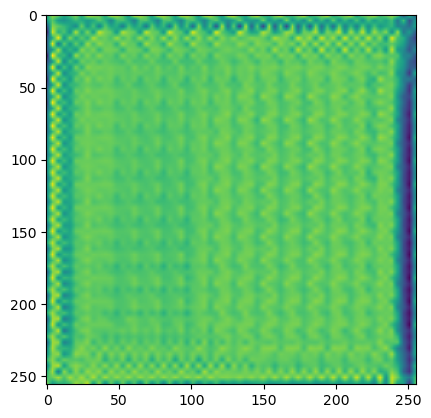

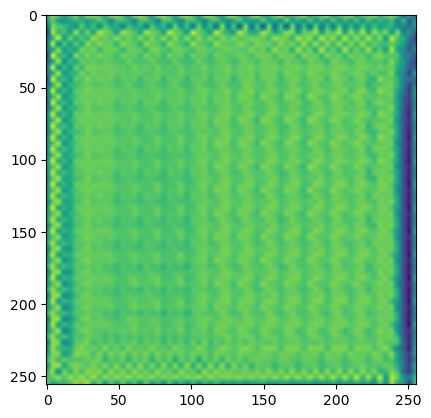

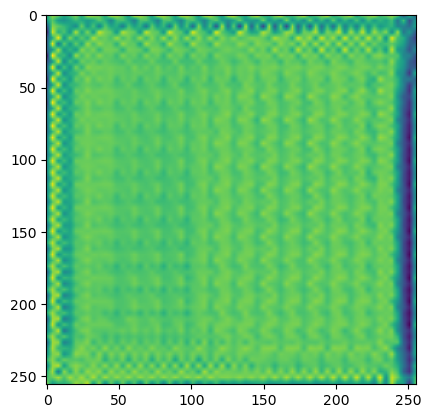

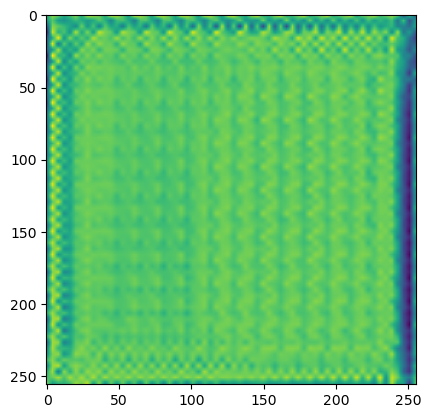

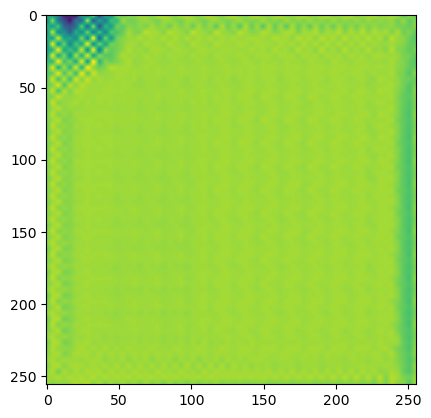

In [21]:
import matplotlib.pyplot as plt

# Assuming gen_output has the shape [batch_size, channels, height, width]
# Convert it back to [batch_size, height, width, channels] for visualization
gen_output1 = gen_output.permute(0, 2, 3, 1).cpu().numpy()

# Loop over the batch and plot images
for i in range(min(5, gen_output.shape[0])):  # Show up to 5 images
    plt.imshow(gen_output1[i])
    plt.show()


In [22]:
import matplotlib.pyplot as plt

# Assuming gen_output has the shape [batch_size, channels, height, width]
# Convert it back to [batch_size, height, width, channels] for visualization
gen_output1 = gen_output.permute(0, 2, 3, 1).tensor.detach().numpy()

# Normalize images to [0, 1] for display (if necessary)
gen_output1 = (gen_output1 - gen_output1.min()) / (gen_output1.max() - gen_output1.min())

# Loop over the batch and plot images
for i in range(min(5, gen_output.shape[0])):  # Show up to 5 images
    plt.imshow(gen_output1[i])
    plt.show()


AttributeError: 'Tensor' object has no attribute 'tensor'

In [23]:
def psnr(output, target, max_val=1.0, eps=1e-10):
    # Example of reshaping target tensor
    output = output.squeeze(1)  # Removes the extra channel dimension, resulting in [batch_size, height, width]
    
    # Now calculate MSE loss
    mse = F.mse_loss(output, target)
    
    # Avoid log(0) by clamping the MSE to a small value
    mse = torch.clamp(mse, min=eps)

    # Compute PSNR
    psnr_value = 20 * torch.log10(max_val / torch.sqrt(mse))
    return psnr_value

# Testing the adjusted loss calculation
for inputs, masks in test_loader:
    inputs, masks = inputs.cuda(), masks.cuda()
    inputs = inputs.permute(0, 3, 1, 2)  # Make sure inputs are in the correct shape
    gen_output = generator(inputs)

    # Resize generated output to match target size (if necessary)
    gen_output = F.interpolate(gen_output, size=(inputs.shape[2], inputs.shape[3]), mode='bilinear', align_corners=True)

    # Compute PSNR for the current batch
    psnr_value = psnr(gen_output, masks)
    print(f"PSNR: {psnr_value.item()}")


PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf
PSNR: -inf


In [24]:
# Assuming 'img1' and 'img2' are your two images as torch tensors
# Example: img1 and img2 are both of shape [batch_size, channels, height, width]

def pearson_correlation(img1, img2):
    # Flatten the images to 1D vectors
    img1_flat = img1.view(-1)
    img2_flat = img2.view(-1)
    
    # Calculate the mean of each image
    mean_img1 = img1_flat.mean()
    mean_img2 = img2_flat.mean()
    
    # Calculate the covariance and standard deviations
    covariance = torch.sum((img1_flat - mean_img1) * (img2_flat - mean_img2))
    std_img1 = torch.sqrt(torch.sum((img1_flat - mean_img1) ** 2))
    std_img2 = torch.sqrt(torch.sum((img2_flat - mean_img2) ** 2))
    
    # Pearson correlation coefficient
    r = covariance / (std_img1 * std_img2)
    
    return r.item()

# Example usage:
# Let's assume img1 and img2 are two torch tensors of the same size (e.g., [batch_size, 1, 256, 256])
img1 = torch.randn(24, 1, 256, 256).cuda()  # Random example tensor
img2 = torch.randn(24, 1, 256, 256).cuda()  # Random example tensor

# Calculate Pearson correlation
pearson_r = pearson_correlation(img1, img2)
print(f"Pearson correlation coefficient: {pearson_r}")


Pearson correlation coefficient: -0.0008161411969922483


In [25]:
# Initialize the reconstructed mask and count mask
reconstructed_mask = torch.zeros_like(torch.tensor(road_mask, dtype=torch.float32))  # Same size as original
count_mask = torch.zeros_like(reconstructed_mask)  # Same size, used for averaging overlaps

patch_height, patch_width = sector_size
num_patches_height = (road_mask.shape[0] - patch_height) // patch_height + 1
num_patches_width = (road_mask.shape[1] - patch_width) // patch_width + 1

# Reconstruct from test_loader predictions
with torch.no_grad():
    for idx, (inputs, _) in enumerate(test_loader):
        inputs = inputs.cuda()
        inputs = inputs.permute(0, 3, 1, 2)  # Ensure correct format
        
        # Get generator output
        gen_output = generator(inputs)
        gen_output = F.interpolate(gen_output, size=(patch_height, patch_width), mode='bilinear', align_corners=True)
        gen_output = gen_output.squeeze(1).cpu()  # Remove unnecessary dimensions
        
        # Find patch position
        row = idx // num_patches_width
        col = idx % num_patches_width
        start_y = row * patch_height
        start_x = col * patch_width

        # Add the patch to the reconstructed mask
        reconstructed_mask[start_y:start_y+patch_height, start_x:start_x+patch_width] += gen_output[0]
        count_mask[start_y:start_y+patch_height, start_x:start_x+patch_width] += 1

# Normalize to get the averaged reconstruction
reconstructed_mask /= torch.clamp(count_mask, min=1)  # Avoid division by zero


In [ ]:
import matplotlib.pyplot as plt

# Convert the tensor to a NumPy array
reconstructed_mask_np = reconstructed_mask.cpu().numpy()

# Display the mask
plt.figure(figsize=(10, 10))
plt.imshow(reconstructed_mask_np, cmap='gray')  # Use grayscale colormap
plt.colorbar()  # Show color scale
plt.title("Reconstructed Road Mask")
plt.axis("off")  # Hide axis for better visualization
plt.show()
